# Risk-Neutral Density Mixture (Bahra) — arbitrage-free by construction
## Portion by: Nico

**One sentence.** SVI fits the *smile* and Heston fits the *dynamics*; this model fits the
**probability distribution itself**, per expiry — so "no negative probabilities" (butterfly) and
"the forward is repriced exactly" (martingale) are properties of the construction, not things we
hope the optimizer gets right.

---
### How to run this notebook

* **On Colab:** upload `surface_all.parquet` next to the notebook (`files.upload()`, as in
  `SVI.ipynb`) **or** mount Drive — the config cell searches the usual team locations, including
  the repo's `Processed/` folder. Everything else is standard Colab libraries.
* **Locally:** just run top-to-bottom from the repo root (it finds `Processed/surface_all.parquet`).
* **Dependencies:** `numpy pandas pyarrow scipy matplotlib` — nothing exotic, no GPU.
* **Runtime map** (laptop; roughly 2x on Colab):

| Section | What happens | Time |
|---|---|---|
| 1–4 | load, split, math + self-checks | seconds |
| 5 | fit the demo day (~40 expiries) | ~10–30 s |
| 6–7 | in-sample + holdout diagnostics, plots | ~1 min |
| 8 | spread-noise uncertainty bands (20 bootstrap refits) | ~15 s |
| 9 | monthly sweep + parameter stability (`SWEEP_MONTHS` refits) | ~10–30 s per month |
| 10 | arbitrage checks, calendar repair + team `SURFACES` export | seconds |

*(Colab is typically 2–3x slower than a laptop; `SWEEP_MONTHS` in the config cell trims Section 9.)*

### Contents
1. Configuration & data · 2. The team split · 3. The model & pricing math (+ self-checks) ·
4. Why free means: a small theorem · 5. Fitting the demo day · 6. Diagnostics (in-sample & holdout) ·
7. Pictures · 8. Uncertainty bands · 9. Monthly sweep + parameter stability ·
10. Arbitrage checks, calendar repair & the team interface · 11. Summary

## 1 — Configuration & data

All knobs live here (same style as the Heston notebook). `QUOTE_DATE = 2023-01-04` is deliberately
the Heston notebook's demo day, so our numbers are directly comparable.

In [1]:
# %pip install -q numpy pandas pyarrow scipy matplotlib     # <- uncomment on a fresh Colab

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, brentq
from scipy.stats import norm

np.random.seed(0)

plt.rcParams.update({                       # one consistent look for every figure
    "figure.dpi": 115, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.30, "axes.titlesize": 10.5,
    "axes.labelsize": 10.5, "legend.frameon": False,
    "font.family": "serif", "mathtext.fontset": "cm",   # LaTeX-style math, no TeX install needed
    "figure.titlesize": 12, "figure.titleweight": "semibold",
})
C_MODEL, C_DATA, C_BAND = "crimson", "steelblue", "lightcoral"

# ------------------------------- knobs ----------------------------------------------
TICKER       = "SPX"
QUOTE_DATE   = "2023-01-04"     # demo day == Heston notebook's day (comparability)
M            = 3                # mixture components
HOLDOUT_FRAC, MIN_VISIBLE, SPLIT_SEED = 0.20, 6, 0     # the team split (do not change)
SWEEP_MONTHS = 12               # Section 8: how many monthly refits (set 3 for a quick pass)

# ------------------------------- locate the data ------------------------------------
CANDIDATES = [
    "Processed/surface_all.parquet",                       # this repo's data folder
    "Processed_data/surface_all.parquet",
    "processed/surface_all.parquet",
    "surface_all.parquet",                                 # files.upload() drops it here
    "/content/drive/MyDrive/Colab Notebooks/OptionsData/OptionsData/processed/surface_all.parquet",
    os.path.expanduser(
        "~/Research/Erdos_Institute/Project/Data/Quant-Finance-project-main/Processed_data/surface_all.parquet"),
]
DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
assert DATA_PATH, ("surface_all.parquet not found.\n"
                   "-> Colab: run files.upload() (see SVI.ipynb) or mount Drive.\n"
                   "-> Local: put it in Processed/ or set DATA_PATH here by hand.")

df = pd.read_parquet(DATA_PATH)
df = df[df["ticker"] == TICKER].copy().reset_index(drop=True)
print(f"{TICKER}: {len(df):,} quotes over {df['quote_date'].nunique()} days   (from {DATA_PATH})")

SPX: 1,462,299 quotes over 249 days   (from Processed/surface_all.parquet)


## 2 — The team split (verbatim from `TrainTestDataSplit.ipynb`)

Same function, same seed, same minimum-visible rule as the SVI and Heston notebooks, so every model
in this repo is trained and judged on the **identical** quotes: random 20% held out inside each
(day, expiry) slice. Per the README we **fit on the visible 80% and score on the held-out 20%**.

In [2]:
def make_holdout(frame, frac, min_vis, seed):
    rng = np.random.default_rng(seed)
    hold = pd.Series(False, index=frame.index)
    for _, sl in frame.groupby(["ticker", "quote_date", "expire_date"]):
        n = len(sl)
        n_hold = min(int(round(frac * n)), max(0, n - min_vis))
        if n_hold > 0:
            hold.loc[rng.choice(sl.index.values, size=n_hold, replace=False)] = True
    return hold


df["is_holdout"] = make_holdout(df, HOLDOUT_FRAC, MIN_VISIBLE, SPLIT_SEED)
print(f"visible {(~df['is_holdout']).sum():,}   held-out {df['is_holdout'].sum():,} "
      f"({100 * df['is_holdout'].mean():.1f}%)")

visible 1,169,769   held-out 292,530 (20.0%)


## 3 — The model, and why the constraints come for free

**Breeden–Litzenberger in three lines.** With risk-neutral density $g$,
$C(K)=e^{-rT}\int_K^\infty (s-K)\,g(s)\,ds \Rightarrow \partial_K C=-e^{-rT}\,\mathbb P[S_T>K]
\Rightarrow \partial_K^2 C=e^{-rT}g(K)\ge 0$. A fitted price curve that is not convex in strike
implies **negative probabilities** — the butterfly arbitrage our `DrawArbitrageCheck.ipynb` tests
with $g(k)$. This model *starts* from a valid density, so convexity is a theorem, not a diagnostic.

**The density.** Normalize $x=S_T/F$ (then $\mathbb E[x]=1$ *is* the forward condition; with this
dataset's zero-carry convention, $F=S_0$ and discounting is 1). Per expiry:

$$ g_x(x)=\sum_{i=1}^{M}\pi_i\,\mathrm{LN}\big(x;\ \text{mean }m_i,\ \text{log-sd }s_i\big),
\qquad \pi_i\ge 0,\ \sum_i\pi_i=1,\ \ \sum_i \pi_i m_i = 1\ \text{(exact)} . $$

**Closed-form prices** (a $\pi$-weighted sum of Black–Scholes-like terms — no quadrature anywhere):

$$ c(k)=\sum_i\pi_i\big[m_i N(d_{1,i})-e^k N(d_{2,i})\big],\qquad
d_{1,i}=\frac{\log m_i-k+s_i^2/2}{s_i},\quad d_{2,i}=d_{1,i}-s_i . $$

The smile is *recovered* afterwards by inverting the plain BS formula in total variance $w$ —
well-posed because that price is strictly increasing in $w$. OTM puts enter as calls via parity
($c = p + 1 - e^k$ under zero carry). Three parameter blocks, $3M-2=7$ numbers per expiry: softmax
weights, free means rescaled so $\sum\pi_i m_i=1$ *identically* (shift-invariant in log-space, which
is also the overflow-safe exponentiation), and softplus vols. *A negative result worth keeping:*
short-tenor fits sometimes produce **needle-thin components** (log-sd near zero — almost an atom of
probability mass). We tested flooring the width at half a percent of log-moneyness with the argument
that no strike grid can see anything narrower; the demo day was indifferent, but several monthly
holdouts degraded by 60–110 bps. The lesson: quotes cannot resolve a needle's *width*, but they very
much resolve its *mass* — pin-like concentrations of mass near the money at short tenors are real and show up in prices — so the needles stay, and the arbitrage diagnostics of Section 10 are built to handle
them exactly (no finite differences). The self-check cell verifies each structural claim instead of
assuming it.

In [3]:
def mixture_call(k, pi, m, s):
    '''Normalized call price of the mixture: c(k) = sum_i pi_i [m_i N(d1_i) - e^k N(d2_i)].'''
    k = np.atleast_1d(np.asarray(k, dtype=float))[:, None]
    d1 = (np.log(m)[None, :] - k + 0.5 * s[None, :] ** 2) / s[None, :]
    d2 = d1 - s[None, :]
    return np.squeeze((pi[None, :] * (m[None, :] * norm.cdf(d1)
                                      - np.exp(k) * norm.cdf(d2))).sum(axis=1))


def mixture_density(x, pi, m, s):
    '''Density of x = S_T/F: mixture of lognormals with mean m_i, log-sd s_i (>= 0 everywhere).'''
    x = np.atleast_1d(np.asarray(x, dtype=float))[:, None]
    mu = np.log(m)[None, :] - 0.5 * s[None, :] ** 2      # log-mean giving E = m
    pdf = np.exp(-0.5 * ((np.log(x) - mu) / s[None, :]) ** 2) / (x * s[None, :] * np.sqrt(2 * np.pi))
    return np.squeeze((pi[None, :] * pdf).sum(axis=1))


def unpack(theta):
    '''Unconstrained theta (3M-2,) -> (pi on the simplex, means with E[x]=1 EXACT, s > 0).'''
    a, b, c = theta[:M - 1], theta[M - 1:2 * M - 2], theta[2 * M - 2:]
    e = np.exp(np.r_[a, 0.0] - np.r_[a, 0.0].max())                    # softmax, overflow-safe
    pi = e / e.sum()
    raw = np.r_[b, 0.0]
    m_un = np.exp(raw - raw.max())                                     # shift-invariant below
    m = m_un / (pi * m_un).sum()                                       # mean-correction: E[x] = 1
    s = 1e-4 + np.log1p(np.exp(np.clip(c, -30, 30)))                   # softplus, s > 0 (no width floor: see note)
    return pi, m, s


def bs_call_normalized(k, w):
    '''Plain BS in (k, total variance w) units: the M = 1, m = 1 special case.'''
    w = np.maximum(np.asarray(w, dtype=float), 1e-16)
    sq = np.sqrt(w)
    d1 = (-np.asarray(k) + w / 2) / sq
    return norm.cdf(d1) - np.exp(np.asarray(k)) * norm.cdf(d1 - sq)


def implied_total_variance(c, k, lo=1e-10, hi=25.0):
    '''Invert c -> w by Brent; valid because the BS price is strictly increasing in w.'''
    out = np.full(np.atleast_1d(k).shape, np.nan)
    kk, cc = np.atleast_1d(k), np.atleast_1d(c)
    for i in range(kk.size):
        intrinsic = max(1.0 - np.exp(kk[i]), 0.0)
        if not (intrinsic < cc[i] < 1.0):
            continue                                     # outside the static no-arbitrage band
        f = lambda w: bs_call_normalized(kk[i], w) - cc[i]
        try:
            out[i] = brentq(f, lo, hi, xtol=1e-14)
        except ValueError:
            pass
    return np.squeeze(out)


# ---- self-checks: the structural claims, verified rather than assumed -----------------
_pi, _m, _s = unpack(np.random.default_rng(1).normal(size=3 * M - 2))
assert abs((_pi * _m).sum() - 1) < 1e-14, "martingale not exact?!"
_x = np.linspace(0.3, 3.0, 2000)
assert mixture_density(_x, _pi, _m, _s).min() >= 0
_w = implied_total_variance(mixture_call(0.1, _pi, _m, _s), 0.1)
assert abs(bs_call_normalized(0.1, _w) - mixture_call(0.1, _pi, _m, _s)) < 1e-12
print(f"self-checks pass:  E[x]-1 = {(_pi * _m).sum() - 1:+.1e}   density >= 0   "
      "price -> w -> price round-trip < 1e-12")

self-checks pass:  E[x]-1 = +0.0e+00   density >= 0   price -> w -> price round-trip < 1e-12


## 4 — Why the means must be *free*: a small theorem we ran into

The "textbook-safe" version pins every component mean to the forward ($m_i\equiv 1$). It looks
conservative — and it **provably cannot fit an equity smile**: for any unit-mean mixture, put–call
symmetry forces

$$ c(-k) = 1 - e^{-k}\big(1-c(k)\big) \qquad\Longrightarrow\qquad w(-k)=w(k), $$

an **exactly symmetric smile with identically zero skew, for every $M$** — adding components buys
curvature, never asymmetry. (Sketch: for one BS call $d_{1,2}(-k)=-d_{2,1}(k)$ gives the identity;
it is affine in $c$, so mixing preserves it; the smile inherits it through the uniqueness of the BS
inversion.) SPX is dominated by negative skew, so the unit-mean model can never work here — we
found this when adding components refused to move the misfit, then proved it. Freeing the means
(mean-corrected, so the forward stays exact) is precisely what buys skew. Verified numerically
below — and shown on real data at the end of Section 5.

In [4]:
kk = np.linspace(-0.4, 0.4, 81)

pi_u, _, s_u = unpack(np.random.default_rng(2).normal(size=3 * M - 2))
m_u = np.ones(M)                                        # unit-mean: every component at the forward
res_unit = mixture_call(-kk, pi_u, m_u, s_u) - (1 - np.exp(-kk) * (1 - mixture_call(kk, pi_u, m_u, s_u)))

pi_f, m_f, s_f = unpack(np.random.default_rng(3).normal(size=3 * M - 2))   # free means
res_free = mixture_call(-kk, pi_f, m_f, s_f) - (1 - np.exp(-kk) * (1 - mixture_call(kk, pi_f, m_f, s_f)))

print(f"put-call-symmetry residual | unit-mean: max {np.abs(res_unit).max():.1e}  "
      "(machine zero -> symmetric smile, zero skew, for ANY M)")
print(f"put-call-symmetry residual | free-mean: max {np.abs(res_free).max():.1e}  "
      "(broken -> skew is representable)")

put-call-symmetry residual | unit-mean: max 2.2e-16  (machine zero -> symmetric smile, zero skew, for ANY M)
put-call-symmetry residual | free-mean: max 1.2e-02  (broken -> skew is representable)


## 5 — Fitting the demo day

Per (day, expiry) slice: convert visible quotes to normalized call prices (puts via parity), weight
each residual by $1/\text{spread}$ (floored) — the same *"how many bid–ask spreads away am I?"*
objective as the Heston notebook — and run `scipy.optimize.least_squares` (`trf`) from 2 starts.
Fitting **prices** keeps every optimizer step closed-form; the smile is recovered once, at the end.
A fraction of a second per expiry — the demo day's ~38 expiries fit in under ten seconds; the cell
prints progress every 10 expiries.

In [5]:
def slice_arrays(sl):
    '''Slice DataFrame -> (k, normalized call mid, floored normalized spread).'''
    k = sl["log_moneyness"].to_numpy(float)
    F = sl["underlying_last"].to_numpy(float)            # zero-carry convention: forward = spot
    cmid = sl["mid"].to_numpy(float) / F
    puts = (sl["type"].to_numpy(str) == "put")
    cmid = np.where(puts, cmid + 1.0 - np.exp(k), cmid)  # parity: c = p + 1 - e^k  (r = 0)
    spr = (sl["ask"] - sl["bid"]).to_numpy(float) / F
    return k, cmid, np.maximum(spr, np.median(spr) * 0.1 + 1e-12)


def fit_slice(k, c, spread, n_starts=2, seed=0):
    '''Fit the free-mean mixture to one expiry; returns (pi, m, s).'''
    rng = np.random.default_rng(seed)

    def residuals(theta):
        pi, m, s = unpack(theta)
        return (mixture_call(k, pi, m, s) - c) / spread

    best, best_cost = None, np.inf
    for j in range(n_starts):
        theta0 = np.r_[rng.normal(0, 0.3, M - 1),        # weights near uniform
                       rng.normal(0, 0.05, M - 1),       # means near the forward
                       np.log(np.expm1(np.clip(0.1 + 0.1 * j + rng.normal(0, 0.02, M), 1e-3, None)))]
        sol = least_squares(residuals, theta0, method="trf", max_nfev=1000)
        if sol.cost < best_cost:
            best, best_cost = sol.x, sol.cost
    return unpack(best)


def fit_day(day_visible, verbose=False):
    '''Fit every expiry of a day on its VISIBLE quotes; returns {tau: (pi, m, s)}.'''
    fits, groups = {}, list(day_visible.groupby("expire_date"))
    for j, (exp_date, sl) in enumerate(groups):
        if len(sl) < MIN_VISIBLE:
            continue
        k, c, spr = slice_arrays(sl)
        fits[float(sl["tau"].iloc[0])] = fit_slice(k, c, spr)
        if verbose and (j + 1) % 10 == 0:
            print(f"    ... {j + 1}/{len(groups)} expiries fitted")
    return dict(sorted(fits.items()))


day_all = df[df["quote_date"] == QUOTE_DATE]
vis, hold = day_all[~day_all["is_holdout"]], day_all[day_all["is_holdout"]]

t0 = time.time()
fits = fit_day(vis, verbose=True)
print(f"\n{QUOTE_DATE}: fitted {len(fits)} expiries on {len(vis):,} visible quotes "
      f"in {time.time() - t0:.0f}s   (holdout waiting: {len(hold):,} quotes)")
print("E[x] - 1 per expiry:", [f"{(p * m).sum() - 1:+.0e}" for p, m, s in fits.values()])

    ... 10/38 expiries fitted


    ... 20/38 expiries fitted


    ... 30/38 expiries fitted



2023-01-04: fitted 38 expiries on 4,408 visible quotes in 7s   (holdout waiting: 1,103 quotes)
E[x] - 1 per expiry: ['-2e-16', '+0e+00', '+2e-16', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '-1e-16', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '+2e-16', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '+0e+00', '-1e-16', '+0e+00', '+0e+00']


**The theorem on real data.** Before the diagnostics, one picture. A single ~30-day slice of the
demo day is fitted twice: once with the means pinned to the forward (the unit-mean version from
Theorem 4.1 — its smile *must* come out symmetric in $k$, whatever the data say) and once with
free, mean-corrected means. The quotes are clearly skewed; only one of the two models can follow them.
One note on how we measure the gap, learned the hard way: the printed number is in **the metric both
fits minimize** (RMS in "bid–ask spreads away"). The unit-mean model is a special case of the free
one, so in that metric it can only do worse, and the size of the gap is what the constraint costs.
Plain IV error can even point the other way, because the fit deliberately gives up on wide-spread
wing quotes, and an unweighted metric then punishes it for exactly that. Always compare two model
classes in the metric they were both fit to.

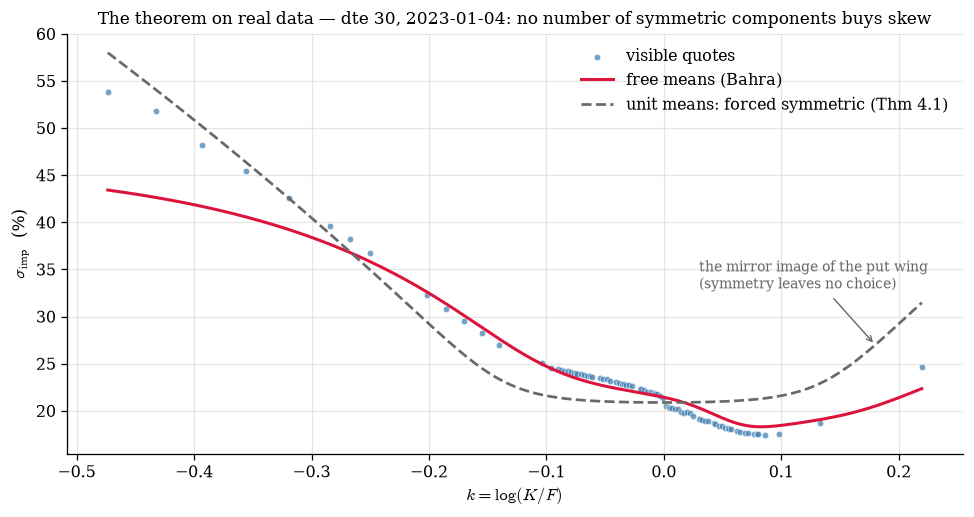

fit objective (spreads away, RMS): free means 2.06   unit means 11.80   <- nested classes: this gap is pure Theorem 4.1
in-sample IV RMS (unweighted)    : free means 196 bps   unit means 254 bps


In [6]:
def fit_slice_unitmean(k, c, spread, n_starts=2, seed=0):
    # best UNIT-MEAN mixture (m_i = 1): the Theorem-4.1 straitjacket, for the picture below
    rng = np.random.default_rng(seed)
    ones = np.ones(M)

    def unpack5(theta5):
        a, cc = theta5[:M - 1], theta5[M - 1:]
        e = np.exp(np.r_[a, 0.0] - np.r_[a, 0.0].max())
        return e / e.sum(), 1e-4 + np.log1p(np.exp(np.clip(cc, -30, 30)))

    def residuals(theta5):
        pi, s = unpack5(theta5)
        return (mixture_call(k, pi, ones, s) - c) / spread

    best, bc = None, np.inf
    for j in range(n_starts):
        t0 = np.r_[rng.normal(0, 0.3, M - 1),
                   np.log(np.expm1(np.clip(0.1 + 0.1 * j + rng.normal(0, 0.02, M), 1e-3, None)))]
        sol = least_squares(residuals, t0, method="trf", max_nfev=1000)
        if sol.cost < bc:
            best, bc = sol.x, sol.cost
    pi, s = unpack5(best)
    return pi, ones, s


tau_pic = min(fits, key=lambda t: abs(t * 365 - 30))
sl_pic = vis[np.isclose(vis["tau"], tau_pic)]
k_p, c_p, spr_p = slice_arrays(sl_pic)
unit_fit = fit_slice_unitmean(k_p, c_p, spr_p)

kk_pic = np.linspace(k_p.min(), k_p.max(), 201)


def smile_pct(prm, kq):
    w = np.atleast_1d(implied_total_variance(np.atleast_1d(mixture_call(kq, *prm)), kq))
    return 100 * np.sqrt(np.where(w > 0, w, np.nan) / tau_pic)


fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.scatter(k_p, 100 * sl_pic["iv"], s=16, color=C_DATA, alpha=0.75,
           edgecolors="white", linewidths=0.4, label="visible quotes")
ax.plot(kk_pic, smile_pct(fits[tau_pic], kk_pic), color=C_MODEL, lw=1.9, label="free means (Bahra)")
ax.plot(kk_pic, smile_pct(unit_fit, kk_pic), color="dimgrey", lw=1.7, ls="--",
        label="unit means: forced symmetric (Thm 4.1)")
k_ann = min(0.9 * k_p.max(), 0.18)
ax.annotate("the mirror image of the put wing\n(symmetry leaves no choice)",
            xy=(k_ann, float(smile_pct(unit_fit, np.array([k_ann]))[0])),
            xytext=(0.03, float(smile_pct(unit_fit, np.array([k_ann]))[0]) + 6),
            fontsize=8.5, color="dimgrey",
            arrowprops=dict(arrowstyle="->", color="dimgrey", lw=0.9))
ax.set_xlabel(r"$k = \log(K/F)$"); ax.set_ylabel(r"$\sigma_{\mathrm{imp}}$  (%)")
ax.set_title(f"The theorem on real data \u2014 dte {int(round(tau_pic * 365))}, {QUOTE_DATE}: "
             "no number of symmetric components buys skew")
ax.legend()
plt.tight_layout(); plt.show()


def slice_iv_rms_bps(prm):
    iv = smile_pct(prm, k_p) / 100
    return 1e4 * np.sqrt(np.nanmean((iv - sl_pic["iv"].to_numpy()) ** 2))


def objective_rms(prm):
    # RMS residual in "bid-ask spreads away" -- the metric BOTH fits actually minimize.
    # The unit-mean class is a SUBSET of the free-mean class, so free <= unit is guaranteed
    # here; the SIZE of the gap is how hard Theorem 4.1 binds on this slice.
    return float(np.sqrt(np.mean(((np.atleast_1d(mixture_call(k_p, *prm)) - c_p) / spr_p) ** 2)))

print(f"fit objective (spreads away, RMS): free means {objective_rms(fits[tau_pic]):.2f}   "
      f"unit means {objective_rms(unit_fit):.2f}   <- nested classes: this gap is pure Theorem 4.1")
print(f"in-sample IV RMS (unweighted)    : free means {slice_iv_rms_bps(fits[tau_pic]):.0f} bps   "
      f"unit means {slice_iv_rms_bps(unit_fit):.0f} bps")

## 6 — Diagnostics: in-sample *and* holdout, side by side

Same three metrics as the rest of the repo, reported for the quotes the model **saw** (visible) and
the quotes it **never saw** (holdout):

* **IV RMSE / MAE** — invert the model price to a Black–Scholes IV, compare with quoted `iv`,
  and report in basis points (1 bp $= 0.01$ vol-percentage points, i.e. $10^{-4}$); wings dominate
  this metric;
* **price RMSE / MAE** in index points (the at-the-money region dominates — the two metrics look at
  opposite ends of the smile on purpose);
* **inside-the-spread %** — how often the model's price lands between bid and ask — roughly,
  "could you trade at the model's price?"

*A note on the absolute IV level.* All team models inherit the dataset's zero-carry convention
(`forward = spot`), while the provider's quoted `iv` embeds the true carry — a systematic offset of
order 100 bps that affects **every** model here identically (backing the forward out of put–call
parity closes most of it, but that is a pipeline change, not a model change). So read these IV
numbers *relative to the other notebooks in this repo* — same data, same split, same convention —
rather than as absolute vol accuracy.

In [7]:
def evaluate(quotes, fits):
    '''Score a set of quotes against fitted per-expiry mixtures. Returns a tidy DataFrame.'''
    rows = []
    for exp_date, sl in quotes.groupby("expire_date"):
        tau = float(sl["tau"].iloc[0])
        if tau not in fits:
            continue
        pi, m, s = fits[tau]
        k, cmid, _ = slice_arrays(sl)
        c_model = np.atleast_1d(mixture_call(k, pi, m, s))
        F = sl["underlying_last"].to_numpy(float)
        w_model = np.atleast_1d(implied_total_variance(c_model, k))
        iv_model = np.sqrt(np.where(w_model > 0, w_model, np.nan) / tau)
        puts = (sl["type"].to_numpy(str) == "put")       # convert back for the bid-ask band check
        p_model = F * np.where(puts, c_model - 1.0 + np.exp(k), c_model)
        inside = (p_model >= sl["bid"].to_numpy(float) - 1e-9) & \
                 (p_model <= sl["ask"].to_numpy(float) + 1e-9)
        rows.append(pd.DataFrame({
            "tau": tau, "k": k, "iv_mkt": sl["iv"].to_numpy(float), "iv_model": iv_model,
            "price_err": p_model - sl["mid"].to_numpy(float), "inside": inside}))
    return pd.concat(rows, ignore_index=True)


def diag_row(name, e):
    ok = np.isfinite(e["iv_model"])
    return {"set": name, "n": len(e),
            "iv_rmse_bps": 1e4 * np.sqrt(np.mean((e.loc[ok, "iv_model"] - e.loc[ok, "iv_mkt"]) ** 2)),
            "iv_mae_bps": 1e4 * np.mean(np.abs(e.loc[ok, "iv_model"] - e.loc[ok, "iv_mkt"])),
            "price_rmse": np.sqrt(np.mean(e["price_err"] ** 2)),
            "price_mae": np.abs(e["price_err"]).mean(),
            "inside_spread": e["inside"].mean()}


ev_in, ev_out = evaluate(vis, fits), evaluate(hold, fits)
diag = pd.DataFrame([diag_row("in-sample (visible 80%)", ev_in),
                     diag_row("HOLDOUT (unseen 20%)", ev_out)]).set_index("set")

print(f"Bahra mixture diagnostics -- {TICKER} {QUOTE_DATE}")
print("-" * 58)
print(diag.round(3).to_string())
print("\n(reference: Heston_model.ipynb, same day, in-sample: IV RMSE 182 bps, price RMSE 9.78)")

Bahra mixture diagnostics -- SPX 2023-01-04
----------------------------------------------------------
                            n  iv_rmse_bps  iv_mae_bps  price_rmse  price_mae  inside_spread
set                                                                                         
in-sample (visible 80%)  4408      162.774     118.547       6.145      2.418          0.298
HOLDOUT (unseen 20%)     1103      169.378     121.769       5.545      2.380          0.285

(reference: Heston_model.ipynb, same day, in-sample: IV RMSE 182 bps, price RMSE 9.78)


## 7 — Pictures: held-out quotes vs. fitted smiles, and the surface with its data

Top grid: four expiries spanning the day — **dots are held-out quotes** (never used in fitting),
the curve is the recovered smile. Middle: the whole fitted surface as a sheet, with the *visible*
quotes as red beads — the data are strings at the quoted expiries; everything between them is
model. Bottom: **the object itself** — this model's entire identity is that it fits the risk-neutral
*density*, so here it is. Left: the fitted densities of the same four expiries — skewed, and where
the day's quotes demand it, *multi-modal* (an upside shoulder alongside the heavy left side):
structure no single lognormal can express. Remember the notes' Section-2 caveat when reading them —
this is the *pricing* distribution, not a forecast. Right: one expiry dissected into its three
$\pi_i$-weighted components against a dashed single lognormal with the same at-the-money variance;
the solid curve's fatter left flank relative to the dashed one is the crash premium, priced.

findfont: Failed to find font weight semibold, now using 700.


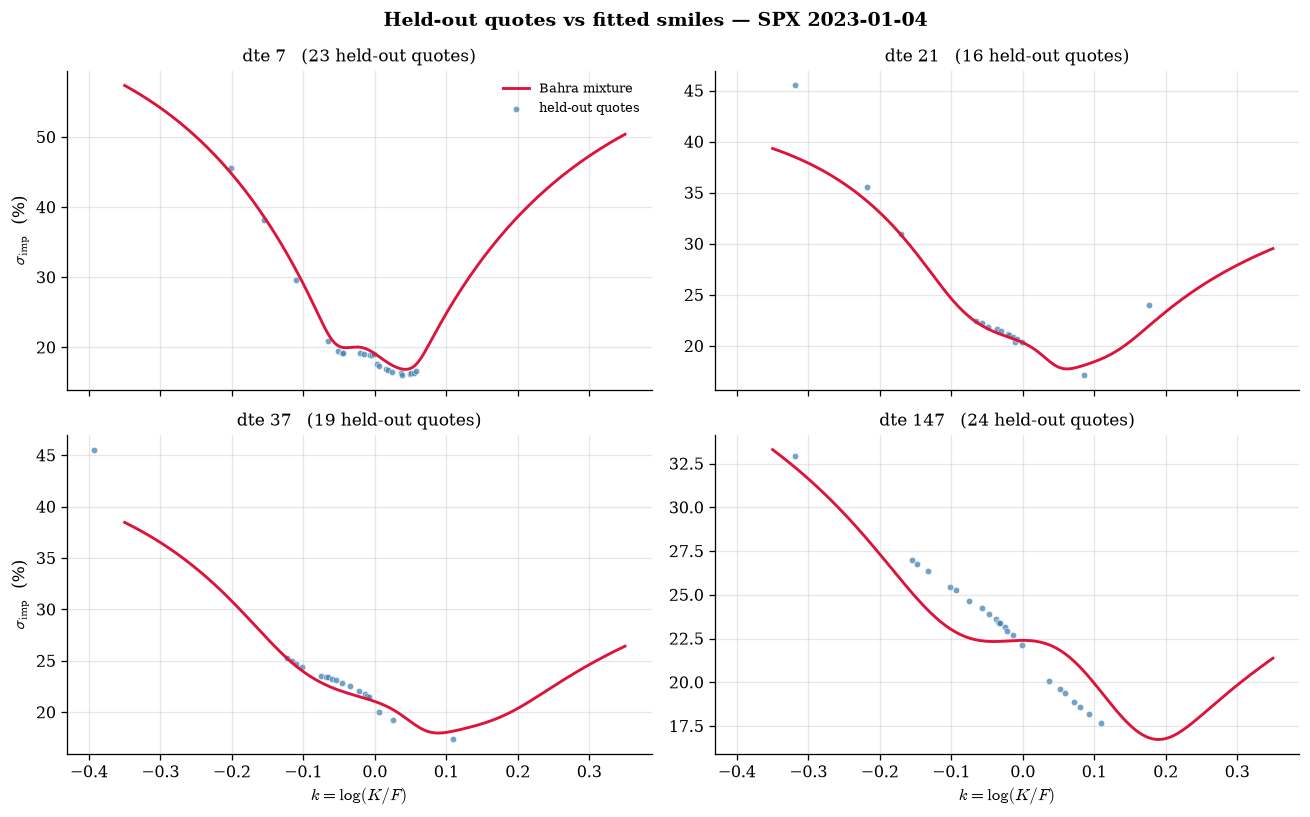

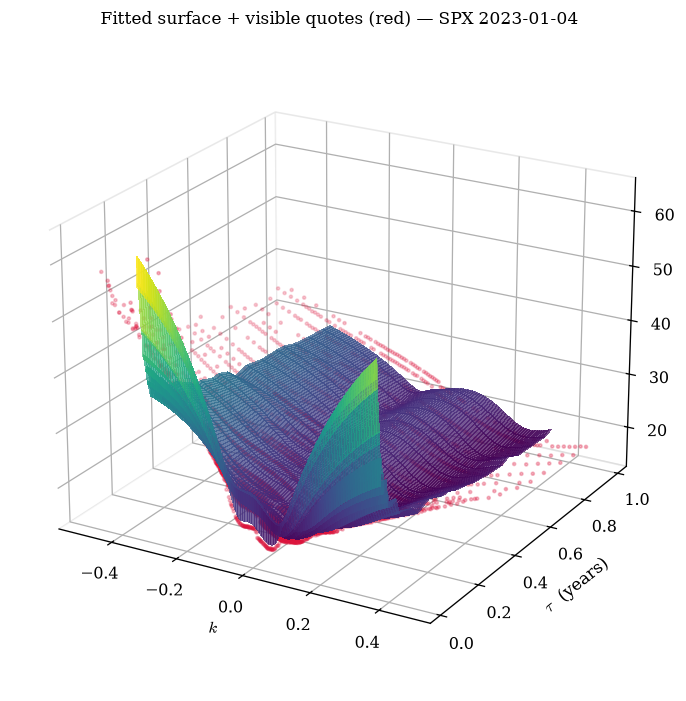

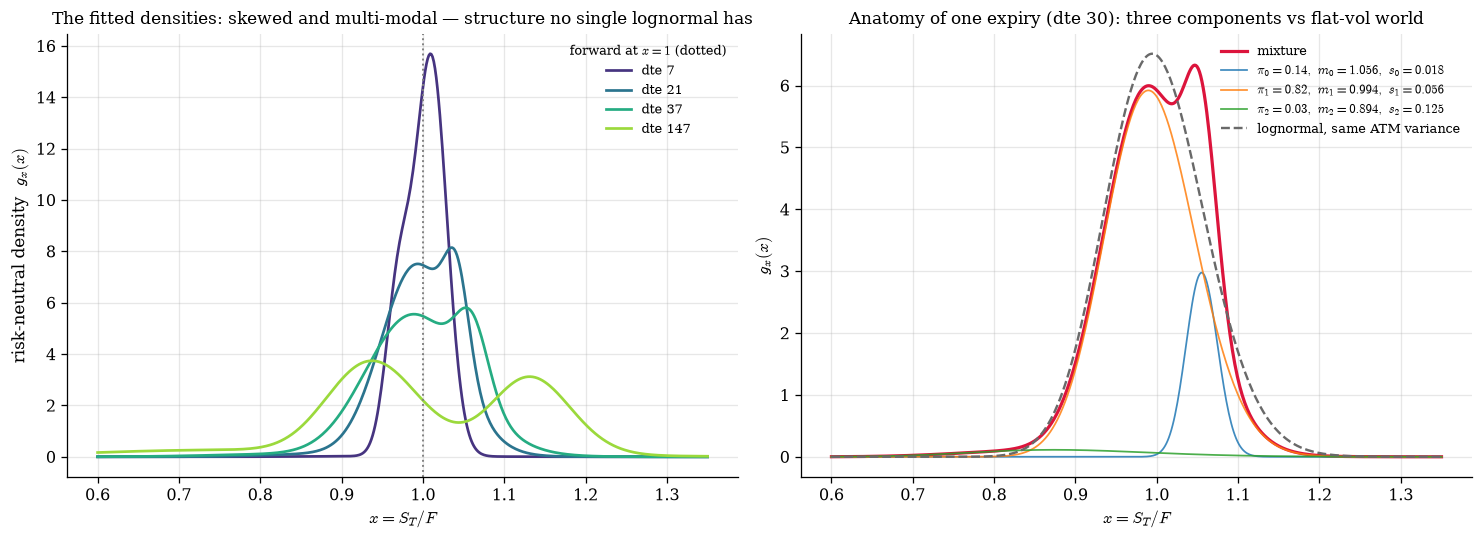

In [8]:
pick = list(fits)[:: max(1, len(fits) // 4)][:4]
kk_plot = np.linspace(-0.35, 0.35, 201)

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.2), sharex=True)
for ax, tau in zip(axes.ravel(), pick):
    pi, m, s = fits[tau]
    w = np.atleast_1d(implied_total_variance(np.atleast_1d(mixture_call(kk_plot, pi, m, s)), kk_plot))
    ax.plot(kk_plot, 100 * np.sqrt(w / tau), color=C_MODEL, lw=1.8, label="Bahra mixture")
    hsl = hold[np.isclose(hold["tau"], tau)]
    ax.scatter(hsl["log_moneyness"], 100 * hsl["iv"], s=16, color=C_DATA, alpha=0.75,
               edgecolors="white", linewidths=0.4, label="held-out quotes")
    ax.set_title(f"dte {int(round(tau * 365))}   ({len(hsl)} held-out quotes)")
axes[0, 0].legend(fontsize=8)
for ax in axes[1]:
    ax.set_xlabel(r"$k = \log(K/F)$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\sigma_{\mathrm{imp}}$  (%)")
fig.suptitle(f"Held-out quotes vs fitted smiles \u2014 {TICKER} {QUOTE_DATE}")
plt.tight_layout(); plt.show()

fig = plt.figure(figsize=(11.5, 6.2))
ax = fig.add_subplot(projection="3d")
tg = np.array(list(fits))
Wg = np.column_stack([np.atleast_1d(implied_total_variance(
    np.atleast_1d(mixture_call(kk_plot, *fits[t])), kk_plot)) for t in tg])
Kg, Tg = np.meshgrid(kk_plot, tg, indexing="ij")
ax.plot_surface(Kg, Tg, 100 * np.sqrt(Wg / Tg), cmap="viridis", alpha=0.75,
                rstride=2, cstride=1, linewidth=0, antialiased=False)
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor("white"); axis.pane.set_edgecolor("lightgrey")
for tau in fits:
    vsl = vis[np.isclose(vis["tau"], tau)]
    ax.scatter(vsl["log_moneyness"], np.full(len(vsl), tau), 100 * vsl["iv"],
               s=3.5, color="crimson", alpha=0.55)
ax.set_xlabel(r"$k$"); ax.set_ylabel(r"$\tau$  (years)"); ax.set_zlabel(r"$\sigma_{\mathrm{imp}}$  (%)")
ax.set_title(f"Fitted surface + visible quotes (red) \u2014 {TICKER} {QUOTE_DATE}")
ax.view_init(elev=22, azim=-60)
plt.tight_layout(); plt.show()

xg_d = np.linspace(0.60, 1.35, 500)
fig, (aL, aR) = plt.subplots(1, 2, figsize=(13.0, 4.8))
for tau, colr in zip(pick, plt.cm.viridis(np.linspace(0.15, 0.85, len(pick)))):
    aL.plot(xg_d, mixture_density(xg_d, *fits[tau]), color=colr, lw=1.7,
            label=f"dte {int(round(tau * 365))}")
aL.axvline(1.0, color="grey", ls=":", lw=1.2)
aL.set_xlabel(r"$x = S_T/F$"); aL.set_ylabel(r"risk-neutral density  $g_x(x)$")
aL.set_title("The fitted densities: skewed and multi-modal \u2014 structure no single lognormal has")
aL.legend(title="forward at $x=1$ (dotted)", fontsize=8, title_fontsize=8)

tau_a = min(fits, key=lambda t: abs(t * 365 - 30))
pi_a, m_a, s_a = fits[tau_a]
aR.plot(xg_d, mixture_density(xg_d, pi_a, m_a, s_a), color=C_MODEL, lw=2.0, label="mixture")
for j in range(M):
    aR.plot(xg_d, mixture_density(xg_d, np.array([pi_a[j]]), np.array([m_a[j]]), np.array([s_a[j]])),
            lw=1.1, alpha=0.85,
            label=fr"$\pi_{j}={pi_a[j]:.2f},\ m_{j}={m_a[j]:.3f},\ s_{j}={s_a[j]:.3f}$")
w_atm = float(np.atleast_1d(implied_total_variance(
    np.atleast_1d(mixture_call(np.array([0.0]), pi_a, m_a, s_a)), np.array([0.0])))[0])
aR.plot(xg_d, mixture_density(xg_d, np.array([1.0]), np.array([1.0]), np.array([np.sqrt(w_atm)])),
        color="dimgrey", ls="--", lw=1.5, label="lognormal, same ATM variance")
aR.set_xlabel(r"$x = S_T/F$"); aR.set_ylabel(r"$g_x(x)$")
aR.set_title(f"Anatomy of one expiry (dte {int(round(tau_a * 365))}): three components vs flat-vol world")
aR.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8 — How sure are we? Spread-noise uncertainty bands

The market never gives one price — it gives an interval $[\mathrm{bid}, \mathrm{ask}]$. That
makes the fit's own uncertainty something we can measure: perturb each visible mid by noise scaled to its
half-spread, refit, repeat, and read off the spread of recovered smiles. Where quotes are dense and
tight the band collapses; where they are wide or sparse it opens — the band is wide exactly where
the data is weak. (Treating the half-spread as one standard deviation is *conservative* on real
data — market-maker mids are smoother than that — so read the band as an upper bound on
quote-driven uncertainty.) Twenty refits of the four plotted expiries take ~15 seconds.

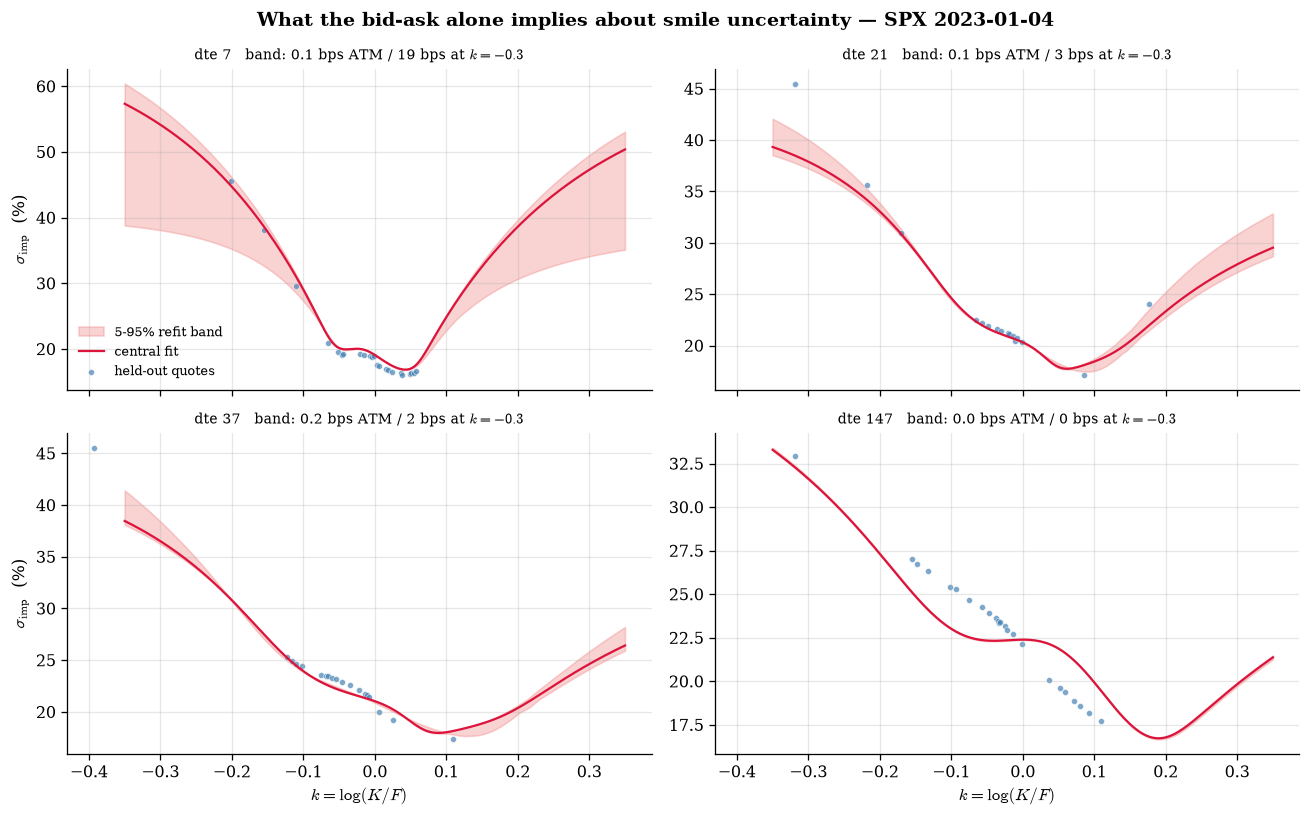

In [9]:
N_BOOT = 20
rng_b = np.random.default_rng(1)

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.2), sharex=True)
for ax, tau in zip(axes.ravel(), pick):
    sl = vis[np.isclose(vis["tau"], tau)]
    k, c, spr = slice_arrays(sl)
    curves = []
    for b in range(N_BOOT):
        cb = c + rng_b.normal(0.0, spr / 2)              # half-spread noise on the visible mids
        pi_b, m_b, s_b = fit_slice(k, cb, spr, seed=100 + b)
        w = np.atleast_1d(implied_total_variance(
            np.atleast_1d(mixture_call(kk_plot, pi_b, m_b, s_b)), kk_plot))
        curves.append(100 * np.sqrt(w / tau))
    lo, hi = np.nanpercentile(np.array(curves), [5, 95], axis=0)
    ax.fill_between(kk_plot, lo, hi, alpha=0.35, color=C_BAND, label="5-95% refit band")
    pi0, m0, s0 = fits[tau]
    w0 = np.atleast_1d(implied_total_variance(np.atleast_1d(mixture_call(kk_plot, pi0, m0, s0)), kk_plot))
    ax.plot(kk_plot, 100 * np.sqrt(w0 / tau), color=C_MODEL, lw=1.4, label="central fit")
    hsl = hold[np.isclose(hold["tau"], tau)]
    ax.scatter(hsl["log_moneyness"], 100 * hsl["iv"], s=14, color=C_DATA, alpha=0.7,
               edgecolors="white", linewidths=0.4, label="held-out quotes")
    atm = np.argmin(np.abs(kk_plot)); wing = np.argmin(np.abs(kk_plot + 0.30))
    ax.set_title(f"dte {int(round(tau * 365))}   band: {hi[atm]-lo[atm]:.1f} bps ATM / "
                 f"{(hi[wing]-lo[wing]):.0f} bps at $k=-0.3$", fontsize=9)
axes[0, 0].legend(fontsize=8)
for ax in axes[1]:
    ax.set_xlabel(r"$k = \log(K/F)$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\sigma_{\mathrm{imp}}$  (%)")
fig.suptitle(f"What the bid-ask alone implies about smile uncertainty \u2014 {TICKER} {QUOTE_DATE}")
plt.tight_layout(); plt.show()

## 9 — Not just one day: the monthly sweep, and parameter stability

One day can flatter any model. This refits everything from scratch on the first trading day of each
month (visible quotes only) and scores its holdout; the pooled row is the number to put next to the
other models. The loop also records the fitted parameters of the **~30-dte expiry** each month —
the project abstract lists *parameter stability* as a judging criterion, and this is where we measure
it. One subtlety makes the plot meaningful: mixtures are **permutation-symmetric** (relabeling
components changes no price), so components are put in canonical order (sorted by mean $m_i$) before
comparing across months. Read the trajectories like a story: the low-mean component is the
crash-scenario mass. Expect the **means** to be stable and the **weights** to be noisy —
overlapping components can trade mass without changing the density much, so the density is pinned
down even when the split into components is not (the table below puts numbers on this).

In [10]:
days = pd.Series(sorted(df["quote_date"].unique()))
monthly = [pd.Timestamp(d) for d in days.groupby(days.dt.to_period("M")).first()][:SWEEP_MONTHS]

rows, stab = [], []
for D in monthly:
    t0 = time.time()
    dd = df[df["quote_date"] == D]
    f = fit_day(dd[~dd["is_holdout"]])
    t30 = min(f, key=lambda t: abs(t * 365 - 30))        # the ~30-dte tenor, tracked monthly
    pi_c, m_c, s_c = f[t30]
    o = np.argsort(m_c)                                  # canonical order (label switching)
    stab.append({"month": str(D.date())[:7], "dte": int(round(t30 * 365)),
                 **{f"pi_{j}": pi_c[o][j] for j in range(M)},
                 **{f"m_{j}": m_c[o][j] for j in range(M)},
                 **{f"s_{j}": s_c[o][j] for j in range(M)}})
    r = diag_row(str(D.date()), evaluate(dd[dd["is_holdout"]], f))
    r["expiries"], r["secs"] = len(f), round(time.time() - t0)
    rows.append(r)
    print(f"  {D.date()}   iv_rmse {r['iv_rmse_bps']:6.0f} bps   price_rmse {r['price_rmse']:7.3f}   "
          f"inside {100 * r['inside_spread']:5.1f}%   ({r['secs']}s)")

tbl = pd.DataFrame(rows).set_index("set")
pooled = {"n": tbl["n"].sum(), "expiries": tbl["expiries"].sum(), "secs": tbl["secs"].sum(),
          "iv_rmse_bps": np.sqrt(np.average(tbl["iv_rmse_bps"] ** 2, weights=tbl["n"])),
          "iv_mae_bps": np.average(tbl["iv_mae_bps"], weights=tbl["n"]),
          "price_rmse": np.sqrt(np.average(tbl["price_rmse"] ** 2, weights=tbl["n"])),
          "price_mae": np.average(tbl["price_mae"], weights=tbl["n"]),
          "inside_spread": np.average(tbl["inside_spread"], weights=tbl["n"])}
tbl.loc[f"POOLED ({len(monthly)} days)"] = pooled
tbl.round(3)

  2023-01-04   iv_rmse    169 bps   price_rmse   5.545   inside  28.5%   (8s)


  2023-02-01   iv_rmse    169 bps   price_rmse   6.618   inside  42.0%   (10s)


  2023-03-01   iv_rmse    245 bps   price_rmse   7.329   inside  18.9%   (8s)


  2023-04-03   iv_rmse    251 bps   price_rmse   6.532   inside  15.0%   (12s)


  2023-05-01   iv_rmse    196 bps   price_rmse   6.892   inside  18.3%   (14s)


...

  2023-09-01   iv_rmse    266 bps   price_rmse   9.213   inside  17.8%   (21s)


  2023-10-02   iv_rmse    183 bps   price_rmse   9.404   inside  12.4%   (12s)


  2023-11-01   iv_rmse    177 bps   price_rmse   8.419   inside  23.9%   (13s)


  2023-12-01   iv_rmse    265 bps   price_rmse   8.198   inside  12.7%   (19s)


,n,iv_rmse_bps,iv_mae_bps,price_rmse,price_mae,inside_spread,expiries,secs
set,,,,,,,,
2023-01-04,1103,169.378,121.769,5.545,2.380,0.285,38,8
2023-02-01,1111,169.318,129.448,6.618,2.453,0.420,38,10
2023-03-01,1150,245.164,155.401,7.329,2.924,0.189,40,8
2023-04-03,1119,251.331,136.285,6.532,2.740,0.150,41,12
2023-05-01,1131,196.473,119.716,6.892,2.871,0.183,38,14
2023-06-01,1109,169.035,127.993,8.650,3.320,0.233,39,16
2023-07-03,1208,242.220,146.356,9.130,3.344,0.322,39,20
2023-08-01,1210,246.492,144.283,9.983,3.666,0.130,38,16
2023-09-01,1222,266.115,143.258,9.213,3.523,0.178,40,21


<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
/var/folders/g3/3n0zg9qn1hq3mcyr51m203jw0000gn/T/ipykernel_15807/946235343.py:3: SyntaxWarning: invalid escape sequence '\p'
  for ax, blk, lab in zip(axes, ("pi", "m", "s"), ("weights $\pi_i$", "means $m_i$", "log-sds $s_i$")):


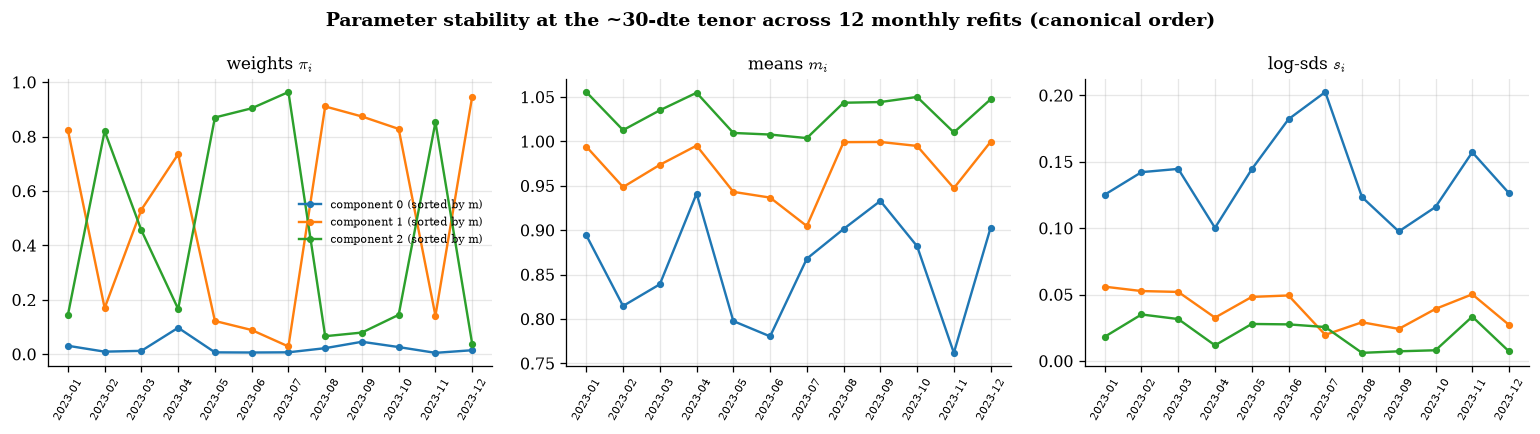

coefficient of variation across months (std/|mean|):
pi_0    1.10
pi_1    0.72
pi_2    0.85
m_0     0.07
m_1     0.03
m_2     0.02
s_0     0.22
s_1     0.32
s_2     0.57


In [11]:
stab_df = pd.DataFrame(stab).set_index("month")
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), sharex=True)
for ax, blk, lab in zip(axes, ("pi", "m", "s"), ("weights $\pi_i$", "means $m_i$", "log-sds $s_i$")):
    for j in range(M):
        ax.plot(stab_df.index, stab_df[f"{blk}_{j}"], marker="o", ms=3.5,
                label=f"component {j} (sorted by m)")
    ax.set_title(lab); ax.grid(alpha=0.3); ax.tick_params(axis="x", rotation=60, labelsize=7)
axes[0].legend(fontsize=7)
fig.suptitle(f"Parameter stability at the ~30-dte tenor across {len(stab_df)} monthly refits (canonical order)")
plt.tight_layout(); plt.show()

drift = stab_df.drop(columns="dte").std() / stab_df.drop(columns="dte").mean().abs()
print("coefficient of variation across months (std/|mean|):")
print(drift.round(2).to_string())

## 10 — Arbitrage checks, a certified calendar repair, and the team `SURFACES` interface

Both checks in the exact form `DrawArbitrageCheck.ipynb` plots:

* **Butterfly — checked twice, both times exactly.** *(i) In density space:* the risk-neutral
  density **is** the model (a mixture of lognormal pdfs), so we evaluate it directly and report its
  minimum — $\ge 0$ by construction. *(ii) In smile space:* the repo's checker finite-differences
  the recovered smile, and for *this* model that check can mislead — short-dated fits may contain
  a near-atomic component (log-sd collapsing toward zero) whose almost-kink turns a fixed-$\varepsilon$
  second difference into large errors of either sign, and near-intrinsic wings add inversion noise
  on top: the check's numerics failing, never the density itself. So we evaluate the **same
  object in closed form** through Breeden–Litzenberger: combining $p(k)=\varphi(d_2)\,g(k)/\sqrt w$
  with $p(k)=u\,g_x(u)$ gives
  $$ g(k) \;=\; e^{k}\, g_x(e^{k})\, \sqrt{w(k)} \,/\, \varphi(d_2(k)) \;\ge\; 0, $$
  positive because every factor is (verified against the finite difference to $8\times10^{-8}$ on
  smooth mixtures). The curves plotted below are exact, per expiry, on that expiry's quoted range.
* **Calendar** — $w(k,\tau)$ non-decreasing in $\tau$ at fixed $k$, tested on the strike band
  quoted by **every** expiry. Per-expiry fits do **not** guarantee this across expiries, so we
  *count* violations honestly — and then **repair them with a certificate, in three lines**: on the
  fitted price grid, replace $c(k,\tau_j)$ by $\max_{i\le j} c(k,\tau_i)$ (the running maximum
  across maturities). Monotone in $\tau$ by construction; still butterfly-free because a pointwise
  maximum of convex functions is convex; vertical-legal because a maximum of non-increasing
  functions with slopes in $[-1,0]$ keeps its slopes there; still inside the static band. It is
  *not* the least-squares projection (prices only move **up** — the full convex-QP projection in the
  main project is the optimal version), but it is a valid arbitrage-free surface, and **how much it
  moves prices is itself useful information**: if it barely moves anything, the per-expiry fits
  were already almost consistent with each other.

The cell exposes `bahra_w_fn(k, tau)` — the interface every team model contributes — and saves the
standard `arb_curves` pickle. To compare models, merge dicts:
`SURFACES.update({"SVI": svi_w_fn, "Heston": heston_w_fn})` before the save.

butterfly (density space, exact) : min density = 2.160e-10  (>= 0 by construction)
calendar repair (cummax on the common band): 156/4598 grid points moved, max displacement 2.98e-03 of forward (= 11.476 index pts); post-repair calendar violations: 0
butterfly (smile space, exact BL identity) : min g(k) = +4.2070e-02  (>= 0)
calendar  : 6 decreases of w in tau across 9 fixed-k lines on the common band [-0.218, +0.074]


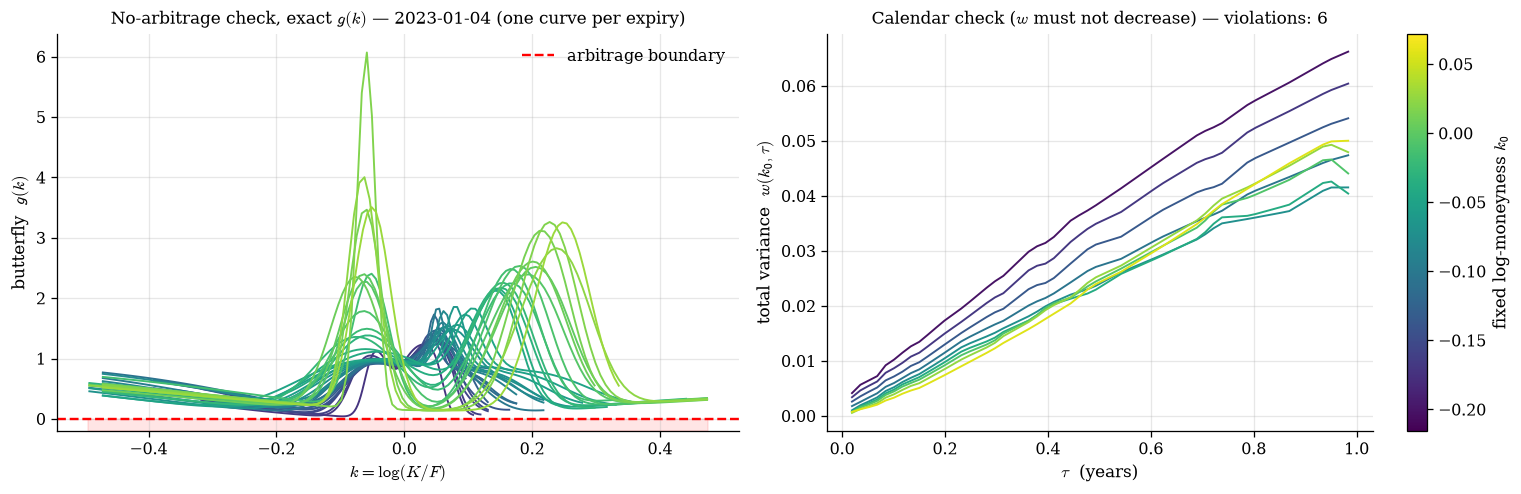

saved arb_curves_bahra_SPX.pkl  (DrawArbitrageCheck-compatible)


In [12]:
def bahra_w_fn(k, tau):
    '''Team interface: total implied variance at (k, tau); linear-in-w between fitted expiries.'''
    k = np.atleast_1d(np.asarray(k, dtype=float))
    tau = np.atleast_1d(np.asarray(tau, dtype=float))
    tg = np.array(list(fits))
    Wg = np.column_stack([np.atleast_1d(implied_total_variance(
        np.atleast_1d(mixture_call(k, *fits[t])), k)) for t in tg])
    out = np.empty(np.broadcast(k, tau).shape)
    kb, tb = np.broadcast_arrays(k, tau)
    for i in range(kb.size):
        out.flat[i] = np.interp(tb.flat[i], tg, Wg[np.argmin(np.abs(k - kb.flat[i]))])
    return out


def g_smile_exact(k, tau):
    '''Exact Gatheral butterfly g(k) via Breeden-Litzenberger: g = e^k g_x(e^k) sqrt(w)/phi(d2).
    No finite differences anywhere -- every factor is closed-form except one well-posed inversion.'''
    k = np.atleast_1d(np.asarray(k, dtype=float))
    pi, m, s = fits[tau]
    w = np.atleast_1d(implied_total_variance(np.atleast_1d(mixture_call(k, pi, m, s)), k))
    d2 = (-k - w / 2) / np.sqrt(w)
    return np.exp(k) * np.atleast_1d(mixture_density(np.exp(k), pi, m, s)) * np.sqrt(w) / norm.pdf(d2)


# (i) density space, exact: the model IS a density -- evaluate it, don't difference it
xg = np.linspace(0.55, 1.6, 800)
dens_min = min(float(np.min(mixture_density(xg, *fits[t]))) for t in fits)

# (ii) smile space, exact BL identity, per expiry over THAT expiry's quoted range
quoted_rng = {float(sl["tau"].iloc[0]): (sl["log_moneyness"].min(), sl["log_moneyness"].max())
              for _, sl in vis.groupby("expire_date")}
g_curves, g_worst = {}, np.inf
for t in fits:
    lo, hi = quoted_rng[t]
    kl = np.linspace(lo + 2e-3, hi - 2e-3, 120)
    g_curves[t] = (kl, g_smile_exact(kl, t))
    g_worst = min(g_worst, np.nanmin(g_curves[t][1]))

# calendar on the band quoted by EVERY expiry
k_common = (max(r[0] for r in quoted_rng.values()), min(r[1] for r in quoted_rng.values()))
k_fixed = np.linspace(k_common[0] + 2e-3, k_common[1] - 2e-3, 9)
tau_fine = np.linspace(min(fits), max(fits), 60)
cal_lines = np.array([bahra_w_fn(np.full_like(tau_fine, k0), tau_fine) for k0 in k_fixed])
cal_viol = int(sum((np.diff(l) < -1e-12).sum() for l in cal_lines))

# --- certified calendar repair: running max across maturities (three lines + diagnostics)
taus_all = np.array(list(fits))
kg_rep = np.linspace(k_common[0] + 2e-3, k_common[1] - 2e-3, 121)
Cgrid = np.column_stack([np.atleast_1d(mixture_call(kg_rep, *fits[t])) for t in taus_all])
Crep = np.maximum.accumulate(Cgrid, axis=1)                      # the repair
disp = Crep - Cgrid
F0 = float(vis["underlying_last"].iloc[0])

print(f"butterfly (density space, exact) : min density = {dens_min:.3e}  (>= 0 by construction)")
print(f"calendar repair (cummax on the common band): {int((disp > 1e-15).sum())}/{Cgrid.size} grid "
      f"points moved, max displacement {disp.max():.2e} of forward (= {F0 * disp.max():.3f} index pts); "
      f"post-repair calendar violations: {int((np.diff(Crep, axis=1) < -1e-15).sum())}")
print(f"butterfly (smile space, exact BL identity) : min g(k) = {g_worst:+.4e}  (>= 0)")
print(f"calendar  : {cal_viol} decreases of w in tau across {len(k_fixed)} fixed-k lines "
      f"on the common band [{k_common[0]:+.3f}, {k_common[1]:+.3f}]")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 4.4))
for t, colr in zip(fits, plt.cm.viridis(np.linspace(0.15, 0.85, len(fits)))):
    a1.plot(*g_curves[t], color=colr, lw=1.2)
a1.axhline(0, color="red", ls="--", lw=1.5, label="arbitrage boundary")
k_band = (min(r[0] for r in quoted_rng.values()), max(r[1] for r in quoted_rng.values()))
a1.fill_between(k_band, -0.2, 0, color="red", alpha=0.10)
a1.set_ylim(bottom=-0.2); a1.set_xlabel(r"$k = \log(K/F)$"); a1.set_ylabel(r"butterfly  $g(k)$")
a1.set_title(f"No-arbitrage check, exact $g(k)$ \u2014 {QUOTE_DATE} (one curve per expiry)")
a1.legend(); a1.grid(alpha=0.3)
cols = plt.cm.viridis(np.linspace(0.05, 0.95, len(k_fixed)))
for j in range(len(k_fixed)):
    a2.plot(tau_fine, cal_lines[j], lw=1.2, color=cols[j])
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(k_fixed[0], k_fixed[-1]))
fig.colorbar(sm, ax=a2, label="fixed log-moneyness $k_0$")
a2.set_xlabel(r"$\tau$  (years)"); a2.set_ylabel(r"total variance  $w(k_0, \tau)$")
a2.set_title(f"Calendar check ($w$ must not decrease) \u2014 violations: {cal_viol}")
a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

import pickle
SURFACES = {"Bahra mixture": bahra_w_fn}
tau_rep = list(fits)[len(fits) // 2]
kline = g_curves[tau_rep][0]                     # representative slice, its quoted range
arb_curves = {"kline": kline, "tau_g": tau_rep, "day": QUOTE_DATE,
              "tau_fine": tau_fine, "k_fixed": k_fixed,
              "g": {"Bahra mixture": g_curves[tau_rep][1]},
              "cal": {n: np.array([w(np.full_like(tau_fine, k0), tau_fine) for k0 in k_fixed])
                      for n, w in SURFACES.items()}}
with open(f"arb_curves_bahra_{TICKER}.pkl", "wb") as fh:
    pickle.dump(arb_curves, fh)
print(f"saved arb_curves_bahra_{TICKER}.pkl  (DrawArbitrageCheck-compatible)")

## 11 — Summary

* **What it is:** per-expiry risk-neutral densities — 3-component free-mean lognormal mixtures
  (Bahra 1997) — with the forward exact by construction, closed-form pricing, and the smile
  recovered by BS inversion.
* **How it differs from our other models:** SVI parametrizes the *smile*, Heston the *dynamics*;
  this parametrizes the *terminal distribution*, so strike-arbitrage-freeness is structural.
* **One honest theorem (Section 4):** unit-mean mixtures provably cannot produce skew — the free
  means are the whole point, not a convenience.
* **Numbers to compare** (same split, same seed): the Section-6 table (demo day = the Heston
  notebook's day) and the Section-9 pooled row.
* **What the extras add:** Section 8 turns the bid–ask itself into smile *uncertainty bands*
  (wide exactly where quotes are wide or missing); Section 9 measures *parameter stability* — the
  judging criterion from our project abstract — with components in canonical order; Section 10
  counts calendar violations honestly, then repairs them with a three-line certificate — and how
  much the repair had to move prices tells you how consistent the fits were.
* **Limitations, stated:** calendar consistency across expiries is *checked and repairable, not
  structural* (Section 10); the dataset's zero-carry convention (`forward = spot`) is inherited by
  every model in this repo — backing the true forward out of put–call parity is the biggest single
  accuracy improvement available to the whole team (~100 bps of systematic IV offset) and the natural next
  pipeline upgrade, alongside an out-of-time test (fit day $t$, price day $t{+}1$); density tails
  beyond $|k|=0.5$ are extrapolation, not data.

*Provenance: this is the team-repo port of the "Bahra-M3" model from my full project workspace,
where it wins an eight-model Pareto comparison (fit vs. arbitrage) under a pre-registered
out-of-sample protocol, and where certified-repair (QP projection), a PINN surface model, and a
GP uncertainty layer live. This notebook is deliberately self-contained.*